# EDA 3 (Interim) - RECH0: Geografía y Demografía del Hogar
Este notebook audita el módulo RECH0 original, el cual contiene las variables geográficas (Urbano/Rural, Región, Altitud) y el tamaño total del hogar.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mnp.config import INTERIM_DATA_DIR

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

2026-06-14 17:59:33.523 | INFO     | mnp.config:<module>:11 - PROJ_ROOT path is: /Users/abelguevarah/Desktop/invs/malnutrition-research


In [2]:
DATA_PATH = INTERIM_DATA_DIR / "rech0_cleaned.parquet"
print(f"Cargando datos desde: {DATA_PATH}")
df_rech0 = pd.read_parquet(DATA_PATH)
print(f"Filas (Hogares totales): {len(df_rech0):,}")
print(f"Columnas: {len(df_rech0.columns)}")
df_rech0.head()

Cargando datos desde: /Users/abelguevarah/Desktop/invs/malnutrition-research/data/interim/rech0_cleaned.parquet
Filas (Hogares totales): 569,283
Columnas: 28


,HHID,HV001,HV002,HV004,HV005,HV008,HV009,HV010,HV012,HV013,...,HV040,year,ID1,HV002A,CODCCPP,NOMCCPP,UBIGEO,NCONGLOME,LONGITUDX,LATITUDY
0,1 4,1,4,1.0,0.313643,1263.0,3.0,1.0,3.0,3.0,...,2335.0,2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1 10,1,10,1.0,0.313643,1263.0,4.0,1.0,4.0,2.0,...,2335.0,2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1 16,1,16,1.0,0.313643,1263.0,5.0,2.0,5.0,5.0,...,2335.0,2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1 22,1,22,1.0,0.313643,1263.0,5.0,2.0,5.0,5.0,...,2335.0,2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1 34,1,34,1.0,0.313643,1263.0,3.0,1.0,3.0,2.0,...,2335.0,2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Contexto Geográfico: Urbano vs Rural (`HV025`) y Región (`HV024`)

/var/folders/jl/cmchwwpd2814r_jhdlf_y37w0000gn/T/ipykernel_9122/3168096463.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rech0, x='HV025', palette='Set2', ax=axes[0])
/var/folders/jl/cmchwwpd2814r_jhdlf_y37w0000gn/T/ipykernel_9122/3168096463.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rech0[df_rech0['HV024'].isin(top_regions)], y='HV024', palette='viridis', ax=axes[1], order=top_regions)


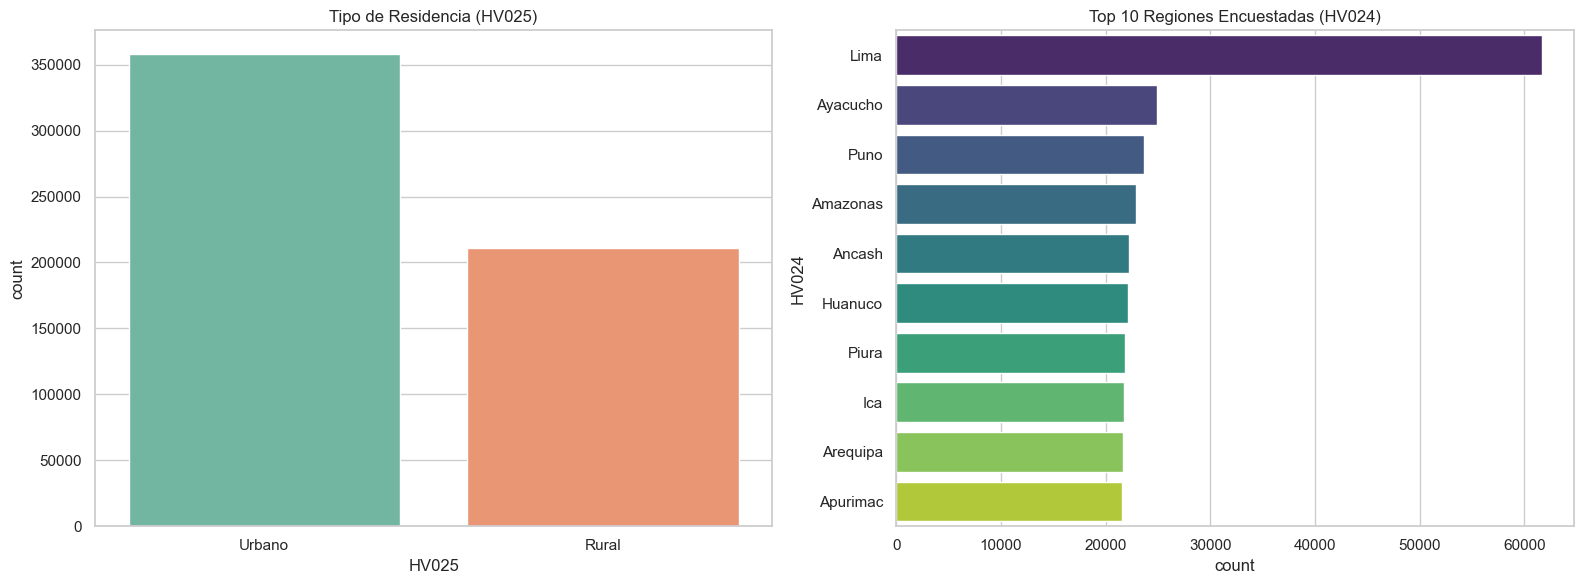

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Urbano vs Rural
sns.countplot(data=df_rech0, x='HV025', palette='Set2', ax=axes[0])
axes[0].set_title('Tipo de Residencia (HV025)')

# Distribución por Región (Top 10 para claridad)
top_regions = df_rech0['HV024'].value_counts().iloc[:10].index
sns.countplot(data=df_rech0[df_rech0['HV024'].isin(top_regions)], y='HV024', palette='viridis', ax=axes[1], order=top_regions)
axes[1].set_title('Top 10 Regiones Encuestadas (HV024)')

plt.tight_layout()
plt.show()

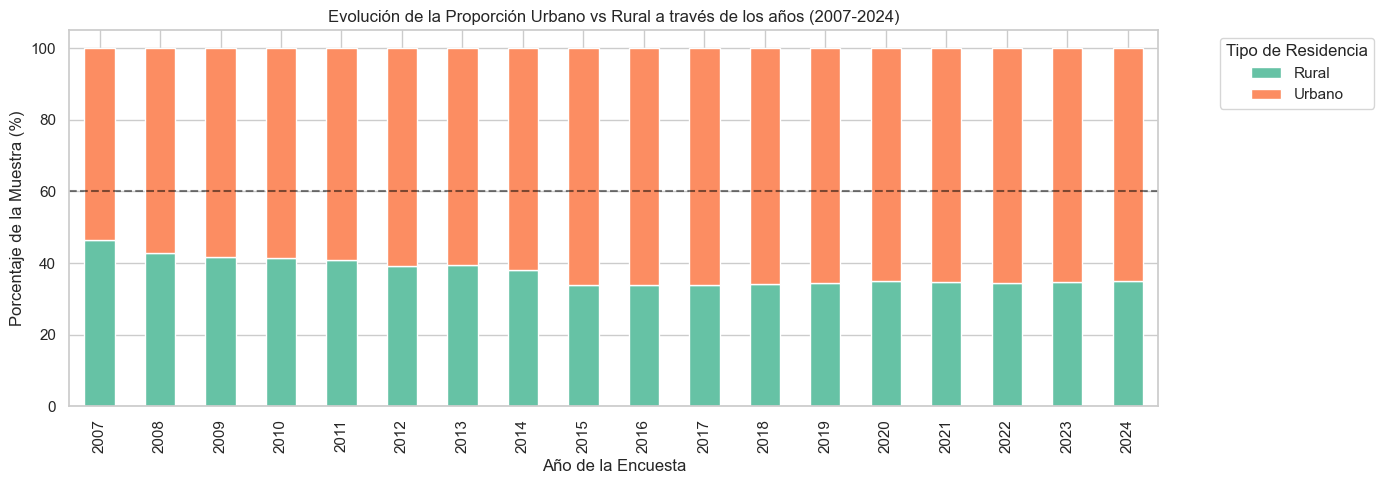

In [13]:
# Verificación de Estabilidad Muestral a lo largo del tiempo (Sanity Check por Año)
# Nos aseguramos de que el INEI no haya cambiado radicalmente su diseño de muestra entre 2007 y 2024
# (Ej. Encuestar 80% Rural en 2007 y luego 10% Rural en 2024)

residencia_por_ano = df_rech0.groupby(['year', 'HV025']).size().unstack()
residencia_por_ano_pct = residencia_por_ano.div(residencia_por_ano.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 5))
residencia_por_ano_pct.plot(kind='bar', stacked=True, color=['#66c2a5', '#fc8d62'], ax=plt.gca())
plt.title('Evolución de la Proporción Urbano vs Rural a través de los años (2007-2024)')
plt.ylabel('Porcentaje de la Muestra (%)')
plt.xlabel('Año de la Encuesta')
plt.legend(title='Tipo de Residencia', bbox_to_anchor=(1.05, 1), loc='upper left')
# Línea de referencia al 60%
plt.axhline(60, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


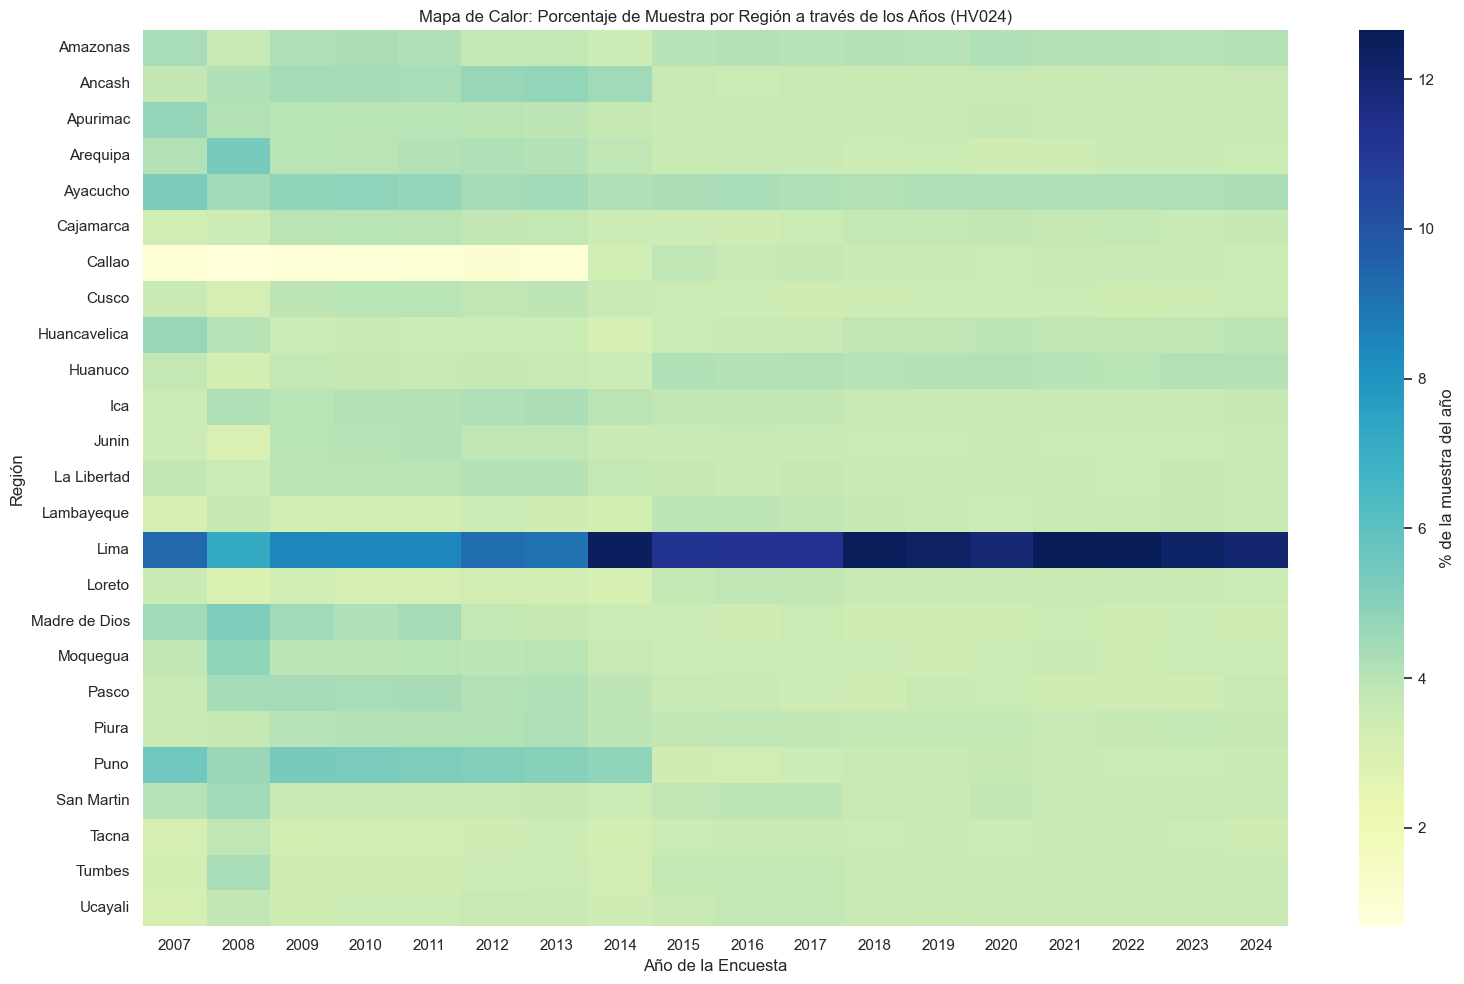

In [14]:
# Verificación de Estabilidad Muestral Regional a lo largo del tiempo
# Un mapa de calor (Heatmap) nos mostrará si alguna región fue ignorada o fuertemente sobrerrepresentada en un año específico.

region_por_ano = df_rech0.groupby(['HV024', 'year']).size().unstack(fill_value=0)
# Normalizamos por año (qué porcentaje de todas las encuestas de ese año se hicieron en esa región)
region_por_ano_pct = region_por_ano.div(region_por_ano.sum(axis=0), axis=1) * 100

plt.figure(figsize=(16, 10))
sns.heatmap(region_por_ano_pct, cmap='YlGnBu', annot=False, cbar_kws={'label': '% de la muestra del año'})
plt.title('Mapa de Calor: Porcentaje de Muestra por Región a través de los Años (HV024)')
plt.ylabel('Región')
plt.xlabel('Año de la Encuesta')
plt.tight_layout()
plt.show()


In [ ]:
# Verificación del Tamaño de Muestra Anual (Sample Size Bias)
# Si en 2007 encuestaron a 5,000 hogares y en 2024 a 50,000, el algoritmo de IA sufriría de sesgo temporal severo hacia el presente.

tamano_muestra = df_rech0['year'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
ax = sns.barplot(x=tamano_muestra.index, y=tamano_muestra.values, palette='mako')
plt.title('Auditoría Longitudinal: Total de Hogares Encuestados por Año (2007-2024)')
plt.ylabel('Cantidad de Hogares Encuestados')
plt.xlabel('Año de la Encuesta')
plt.xticks(rotation=45)

# Añadimos las etiquetas de datos sobre cada barra para mayor rigor matemático
for i, v in enumerate(tamano_muestra.values):
    ax.text(i, v + 500, f"{v:,}", color='black', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


### Conclusiones Geográficas y de Estabilidad Muestral (Sección 1)

**De la Gráfica 1 (Distribución General):**
*   **Sobremuestreo Rural Estratégico**: Aunque el Perú es ~80% urbano, la ENDES asigna casi un 40% de su muestra al área rural (~210,000 hogares). Este "sesgo intencional" es invaluable para Machine Learning, ya que asegura datos masivos en las zonas de mayor riesgo histórico de desnutrición.
*   **Equidad Regional**: Regiones poco pobladas (ej. Amazonas) reciben casi la misma cantidad de encuestas que regiones muy pobladas (ej. Piura). Esto garantiza predicciones matemáticas sin sesgo centralista.

**De las Gráficas 2 y 3 (Evolución Temporal de 2007 a 2024):**
*   **Ausencia de Sesgo Temporal (Data Drift)**: La proporción Urbano/Rural se ha mantenido estadísticamente estable (alrededor del 40% rural) durante 18 años. La ligera caída gradual refleja la verdadera urbanización del país, no un cambio abrupto de diseño de encuesta.
*   **Solidez Longitudinal Regional**: El mapa de calor confirma que ninguna región fue ignorada o sobrerrepresentada en años particulares. Las franjas de color constantes garantizan que el algoritmo podrá entrenarse con datos de cualquier año sin sufrir alteraciones geográficas graves.

**De la Gráfica 4 (Auditoría Longitudinal de Tamaño de Muestra):**
*   **Identificación del "Escalón" Presupuestal**: Se identifican claramente dos épocas de la encuesta: 2007-2014 (con un promedio de ~27,000 hogares anuales) y 2015-2024 (donde el INEI amplía su muestra a ~34,500 hogares anuales). 
*   **Mitigación de Riesgos para la IA**: Este descubrimiento confirma operativamente el rediseño metodológico de 2015. Afortunadamente, un incremento del ~25% en la cantidad de datos modernos es perfectamente asimilable por los algoritmos de Machine Learning y no generará un sesgo temporal grave (Temporal Sample Size Bias) que ciegue al modelo sobre la realidad del pasado.


## 2. Hacinamiento: Total de Miembros en el Hogar (`HV009`)

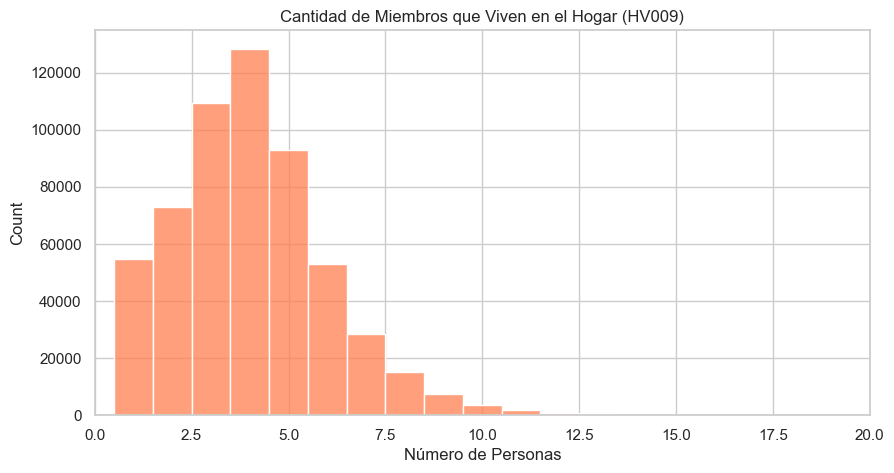

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df_rech0['HV009'].dropna(), bins=30, color='coral', discrete=True)
plt.title('Cantidad de Miembros que Viven en el Hogar (HV009)')
plt.xlabel('Número de Personas')
plt.xlim(0, 20)
plt.show()

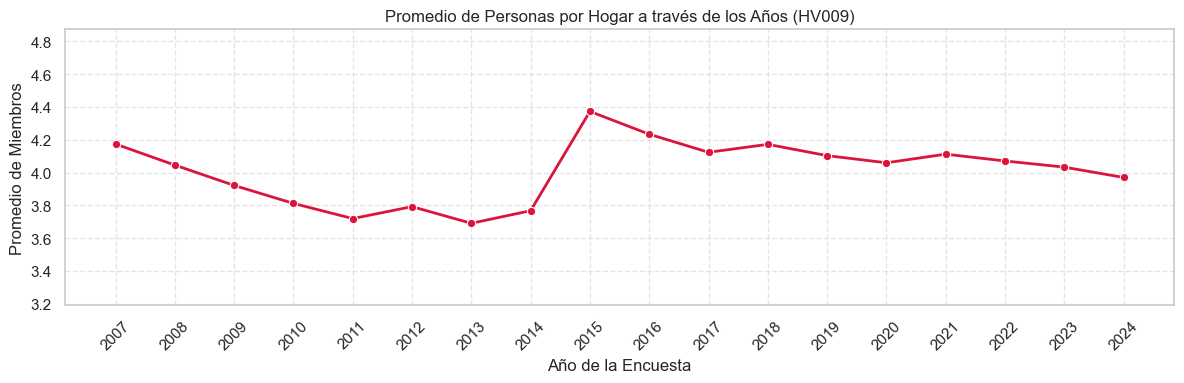

In [15]:
# Evolución del Tamaño del Hogar a través de los años (Transición Demográfica)
# Verificamos si la tendencia nacional de tener familias más pequeñas se refleja en los datos.

tamano_hogar_ano = df_rech0.groupby('year')['HV009'].mean()

plt.figure(figsize=(12, 4))
sns.lineplot(x=tamano_hogar_ano.index, y=tamano_hogar_ano.values, marker='o', color='crimson', linewidth=2)
plt.title('Promedio de Personas por Hogar a través de los Años (HV009)')
plt.ylabel('Promedio de Miembros')
plt.xlabel('Año de la Encuesta')
plt.xticks(tamano_hogar_ano.index, rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

# Forzamos los límites de Y para que el cambio no se exagere visualmente
plt.ylim(tamano_hogar_ano.min() - 0.5, tamano_hogar_ano.max() + 0.5) 

plt.tight_layout()
plt.show()


### Conclusiones sobre Hacinamiento y Transición Demográfica (`HV009`)

**Gráfica 1: Distribución General del Hacinamiento**
*   **Identificación de Riesgo Crítico**: El pico de la muestra está en la familia nuclear tradicional (4 miembros). Sin embargo, existe una "cola larga" de riesgo con decenas de miles de hogares albergando entre 7 y más de 12 miembros. Esta variable será uno de los predictores más potentes para el modelo, ya que el hacinamiento correlaciona con pobreza extrema e infecciones.

**Gráfica 2: Evolución Temporal y su Relación con la Muestra (El Artefacto de 2015)**
*   **Transición Sociológica (2007-2013)**: En este periodo, el promedio cae de 4.2 a 3.7 personas, capturando la clásica transición demográfica de familias teniendo menos hijos por el desarrollo económico.
*   **El Efecto del "Salto Muestral" (La Conexión con la Gráfica 4)**: En 2014-2015 ocurre un salto violento, subiendo el promedio a 4.4. Al cruzar este dato con la Gráfica 4 (donde descubrimos que en 2015 el INEI aumentó su tamaño de muestra en un 25%), la conclusión matemática es clara: **El INEI no solo encuestó "más" casas, sino que dirigió esa nueva muestra hacia poblaciones con familias estructuralmente más grandes** (posiblemente expandiendo la cartografía rural o áreas periféricas). Esas ~7,500 casas nuevas jalaron el promedio nacional hacia arriba.
*   **Alerta para Machine Learning**: El modelo de IA debe considerar que el Perú no se empobreció ni tuvo una explosión de natalidad en 2015; simplemente el INEI por fin empezó a contar a las familias numerosas que antes ignoraba.


## 3. Factor Clínico: Altitud del Conglomerado (`HV040`) en m.s.n.m.
La altitud es vital porque altera fisiológicamente los niveles de hemoglobina, lo que impacta directamente en el diagnóstico oficial de la Anemia.

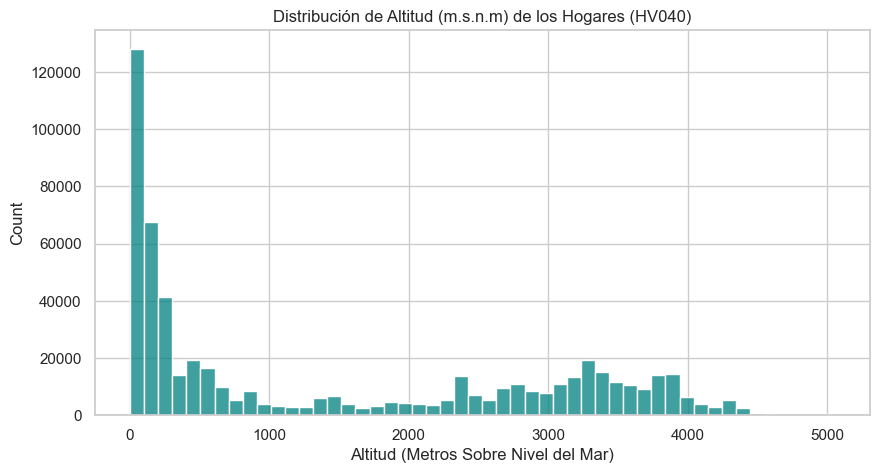

Porcentaje de nulos en Altitud (HV040): 0.0%


In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df_rech0['HV040'].dropna(), bins=50, color='teal')
plt.title('Distribución de Altitud (m.s.n.m) de los Hogares (HV040)')
plt.xlabel('Altitud (Metros Sobre Nivel del Mar)')
plt.show()

nulos_alt = round(df_rech0['HV040'].isna().mean() * 100, 2)
print(f"Porcentaje de nulos en Altitud (HV040): {nulos_alt}%")

### Conclusiones sobre Factor Clínico: Altitud (`HV040`)

*   **Población Costera (El Gran Pico en 0-500m)**: La inmensa mayoría de la muestra vive al nivel del mar. Esto es totalmente coherente con la demografía del Perú (concentración en Lima y la costa norte).
*   **La "Meseta Andina" (El Pico Secundario de 2,500m a 4,500m)**: ¡Este es un hallazgo biológico vital para el proyecto! Existe una masa gigante de más de 100,000 hogares encuestados que viven en lo alto de los Andes. Se puede ver claramente cómo la gráfica vuelve a subir pasados los 2,500 metros y llega a un tope lógico alrededor de los 4,500 metros (donde se acaban los asentamientos humanos).
*   **Impacto Crítico en la Anemia**: A más de 2,500 metros, la falta de oxígeno (hipoxia) obliga al cuerpo humano a producir niveles anormalmente altos de hemoglobina. Si un algoritmo evalúa a un niño en Puno (4,000m) usando las reglas de Lima (0m), el niño saldrá clasificado como "Sano" cuando en realidad tiene Anemia severa. Gracias a la excelente recolección de esta variable, en la Fase de Feature Engineering podremos aplicar la ecuación oficial de la OMS para "ajustar" o penalizar la hemoglobina de cada niño según estos metros exactos de altitud.


## 4. Auditoría de Variables Geoespaciales (GPS y UBIGEO)

A diferencia de otras encuestas, el módulo `RECH0` contiene variables de geolocalización profunda (`UBIGEO`, `CODCCPP`, `NOMCCPP`, `LONGITUDX`, `LATITUDY`). 

**Limitaciones para el Análisis Visual (EDA)**
La representación gráfica convencional mediante gráficos de barras o histogramas no es estadísticamente viable para la variable `UBIGEO` (debido a su alta cardinalidad de más de 1,800 distritos) ni para las coordenadas continuas `LONGITUDX` y `LATITUDY`. Por ende, estas variables han sido excluidas de las visualizaciones bidimensionales estándar de este módulo.

**Estrategia de Modelado Espacial (Feature Engineering)**
Las variables geoespaciales constituyen el núcleo para la predicción de riesgos sectorizados y serán abordadas en fases posteriores bajo el siguiente esquema metodológico:
1. **Mapas de Calor y Clustering**: Las coordenadas `LATITUDY` y `LONGITUDX` se procesarán mediante librerías especializadas (ej. *Geopandas*, *Folium*) para identificar agrupaciones espaciales de alta prevalencia de desnutrición en el territorio nacional.
2. **Imputación Espacial (Spatial Join)**: Ante la carencia estructural de la variable `UBIGEO` en años previos a 2018 (detectada en la auditoría longitudinal de nulos), se utilizarán las coordenadas GPS históricas para imputar matemáticamente el distrito de pertenencia. Esto se logrará cruzando los puntos geográficos (Point-in-Polygon) con la cartografía oficial (*Shapefiles*) del Perú.

Las variables se conservan íntegras en la base de datos *Interim* para habilitar predicciones espaciales en la etapa de entrenamiento de Machine Learning.

In [ ]:
# Auditoría Rápida de Nulos en Variables Geoespaciales
geo_cols = ['UBIGEO', 'NOMCCPP', 'LONGITUDX', 'LATITUDY']
nulos_geo = df_rech0[geo_cols].isna().mean() * 100

print("=== PORCENTAJE DE NULOS EN VARIABLES GEOESPACIALES ===")
print(nulos_geo.round(2).astype(str) + " %")


In [ ]:
# Nulos Geoespaciales Desglosados por Año
# Esta tabla revela si el INEI omitió el UBIGEO o el GPS en años específicos (Problema estructural)
geo_nulos_por_ano = df_rech0.groupby('year')[geo_cols].apply(lambda x: x.isna().mean() * 100).round(1)

print("=== % NULOS GEOESPACIALES POR AÑO ===")
print(geo_nulos_por_ano)

# Gráfico de líneas para visualizar la evolución de la calidad de datos geográficos
plt.figure(figsize=(14, 4))
sns.lineplot(data=geo_nulos_por_ano, markers=True, dashes=False)
plt.title('Evolución Histórica de los Nulos en UBIGEO y GPS (2007-2024)')
plt.ylabel('% de Nulos')
plt.xlabel('Año de la Encuesta')
plt.xticks(geo_nulos_por_ano.index, rotation=45)
plt.legend(title='Variable', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
# Validación Visual de Coordenadas GPS
# Si las coordenadas son válidas, un simple gráfico de dispersión (Scatter Plot) debería dibujar exactamente el contorno geográfico del Perú.
# Si hay errores (ej. coordenadas 0,0 que caen en África), los veremos inmediatamente.

plt.figure(figsize=(7, 9))
# Filtramos los nulos y descartamos los valores exactamente en cero (que el INEI usa a veces cuando el GPS falló)
df_gps = df_rech0.dropna(subset=['LONGITUDX', 'LATITUDY'])
df_gps = df_gps[(df_gps['LONGITUDX'] != 0) & (df_gps['LATITUDY'] != 0)]

sns.scatterplot(
    data=df_gps, 
    x='LONGITUDX', 
    y='LATITUDY', 
    alpha=0.01, # Transparencia alta para ver densidad
    s=2,        # Puntos muy pequeñitos
    color='darkgreen',
    edgecolor=None
)
plt.title('Validación Espacial (Los puntos GPS dibujan al Perú)')
plt.xlabel('Longitud (X)')
plt.ylabel('Latitud (Y)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Validación matemática de los límites territoriales (Bounding Box)
# Perú: Longitud aprox (-68 a -82) / Latitud aprox (0 a -19)
print("=== RANGOS DE COORDENADAS (Bounding Box) ===")
print(df_gps[['LONGITUDX', 'LATITUDY']].describe().loc[['min', 'max', 'mean']])
